In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
from scipy.stats import normaltest
from sklearn.metrics import roc_curve, auc
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats 
import random
import scipy

gpp.set_aesthetics(context = 'paper')

Added October 2025 for further benchmarking of Jacquere performance

In [3]:
reads_df=pd.read_table("../Data/counts-EK20250627_Jacquere_allinone.txt")
reads_df=reads_df.drop(["Empty","Construct IDs"],axis=1)
reads_df

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB,CP0082_pDNA
0,AAAAAAGAAAGGATACGTCC,537,545,637,587,202
1,AAAAACAGCTGATGAAACCT,693,1170,1367,1544,235
2,AAAAACCTGGGAAAGATATA,1742,2360,1911,2648,339
3,AAAAAGAGGCGGCATTACAG,1530,1881,2557,2291,415
4,AAAAAGATAGATGTGCTAAA,60,36,96,79,303
...,...,...,...,...,...,...
60545,TTTGTGGAGCCGGTACATGA,3091,3213,2809,3054,461
60546,TTTGTGGGTACATCTAACCC,1273,1289,977,1554,224
60547,TTTGTGGTAGGAGTAGGTGT,762,412,757,584,269
60548,TTTGTGTATTACCTCAGGAA,370,678,453,658,200


In [4]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
condition_columns = ['A375_CP0082_repA',
       'A375_CP0082_repB', 'A549_CP0082_repA', 'A549_CP0082_repB',
       'CP0082_pDNA']
lognorm_df = reads_df.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove('CP0082_pDNA')
lognorm_df

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB,CP0082_pDNA
0,AAAAAAGAAAGGATACGTCC,2.713788,2.691524,3.006379,2.744796,3.473443
1,AAAAACAGCTGATGAAACCT,3.031349,3.669182,4.008814,4.000054,3.673393
2,AAAAACCTGGGAAAGATATA,4.250788,4.623112,4.466389,4.740195,4.166903
3,AAAAAGAGGCGGCATTACAG,4.074037,4.310656,4.869930,4.539656,4.443945
4,AAAAAGATAGATGTGCTAAA,0.697130,0.444304,1.042846,0.821725,4.014447
...,...,...,...,...,...,...
60545,TTTGTGGAGCCGGTACATGA,5.044659,5.052619,5.001102,4.938798,4.588971
60546,TTTGTGGGTACATCTAACCC,3.825928,3.798418,3.559569,4.008788,3.609773
60547,TTTGTGGTAGGAGTAGGTGT,3.152216,2.358262,3.226633,2.738509,3.853975
60548,TTTGTGTATTACCTCAGGAA,2.272382,2.962064,2.585739,2.886110,3.460386


In [5]:
#remove underrepresented sgRNAs
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms['CP0082_pDNA'] - filtered_lognorms['CP0082_pDNA'].mean())/filtered_lognorms['CP0082_pDNA'].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
filtered_lognorms

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB,CP0082_pDNA
0,AAAAAAGAAAGGATACGTCC,2.713788,2.691524,3.006379,2.744796,3.473443
1,AAAAACAGCTGATGAAACCT,3.031349,3.669182,4.008814,4.000054,3.673393
2,AAAAACCTGGGAAAGATATA,4.250788,4.623112,4.466389,4.740195,4.166903
3,AAAAAGAGGCGGCATTACAG,4.074037,4.310656,4.869930,4.539656,4.443945
4,AAAAAGATAGATGTGCTAAA,0.697130,0.444304,1.042846,0.821725,4.014447
...,...,...,...,...,...,...
60253,TTTGTGGAGCCGGTACATGA,5.044659,5.052619,5.001102,4.938798,4.588971
60254,TTTGTGGGTACATCTAACCC,3.825928,3.798418,3.559569,4.008788,3.609773
60255,TTTGTGGTAGGAGTAGGTGT,3.152216,2.358262,3.226633,2.738509,3.853975
60256,TTTGTGTATTACCTCAGGAA,2.272382,2.962064,2.585739,2.886110,3.460386


In [6]:
#get log fold change from pDNA
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["CP0082_pDNA"]
lfc_df=lfc_df.drop("CP0082_pDNA",axis=1)
lfc_df

,Construct Barcode,A375_CP0082_repA,A375_CP0082_repB,A549_CP0082_repA,A549_CP0082_repB
0,AAAAAAGAAAGGATACGTCC,-0.759655,-0.781919,-0.467064,-0.728647
1,AAAAACAGCTGATGAAACCT,-0.642044,-0.004211,0.335421,0.326662
2,AAAAACCTGGGAAAGATATA,0.083885,0.456208,0.299485,0.573292
3,AAAAAGAGGCGGCATTACAG,-0.369908,-0.133289,0.425985,0.095711
4,AAAAAGATAGATGTGCTAAA,-3.317317,-3.570143,-2.971601,-3.192722
...,...,...,...,...,...
60253,TTTGTGGAGCCGGTACATGA,0.455688,0.463648,0.412131,0.349827
60254,TTTGTGGGTACATCTAACCC,0.216155,0.188645,-0.050204,0.399015
60255,TTTGTGGTAGGAGTAGGTGT,-0.701758,-1.495712,-0.627342,-1.115466
60256,TTTGTGTATTACCTCAGGAA,-1.188004,-0.498322,-0.874647,-0.574276


In [7]:
#Replicate correlation is satisfactory: average replicates

condition_map = {'A375_CP0082_repA': 'Jacquere A375',
                 'A375_CP0082_repB': 'Jacquere A375',
                 'A549_CP0082_repA': 'Jacquere A549',
                 'A549_CP0082_repB': 'Jacquere A549'}

long_lfcs = (lfc_df.melt(id_vars='Construct Barcode',
                         var_name='condition', value_name='lfc'))

long_lfcs['condition'] = long_lfcs['condition'].map(condition_map)
lfcs_replicates_averaged = (long_lfcs.groupby(['Construct Barcode', 'condition'])
            .agg(sgRNA_lfc = ('lfc', 'mean'))
            .reset_index())
lfcs_replicates_averaged

,Construct Barcode,condition,sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,-0.770787
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,-0.597856
2,AAAAACAGCTGATGAAACCT,Jacquere A375,-0.323128
3,AAAAACAGCTGATGAAACCT,Jacquere A549,0.331041
4,AAAAACCTGGGAAAGATATA,Jacquere A375,0.270047
...,...,...,...
120511,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,-0.871404
120512,TTTGTGTATTACCTCAGGAA,Jacquere A375,-0.843163
120513,TTTGTGTATTACCTCAGGAA,Jacquere A549,-0.724461
120514,TTTGTTGGATACGAAGTGAA,Jacquere A375,0.558674


In [8]:
#read in guide level annotations (supplementary file from manuscript)
guide_mappings_compressed = pd.read_csv("../Data/Jacquere_PerGuideAnnotations.csv")

#get target-level information as a unique row (guides that have numerous targets are thus repeated)
guide_mapping=guide_mappings_compressed.apply(lambda x: x.str.split("|")).explode(column=[col for col in guide_mappings_compressed.columns if col not in ["sgRNA Sequence","Other Target Matches"]])
guide_mapping["sgRNA Sequence"]=guide_mapping["sgRNA Sequence"].apply(lambda x: "".join(x))
guide_mapping=guide_mapping.drop("Other Target Matches",axis=1)

#identify additional genes to which each guide maps; gene effects should be determined from ALL mapping guides, regardless of intended target
guides_with_additional_genesmapped= guide_mappings_compressed[guide_mappings_compressed["Other Target Matches"]!="[]"][["sgRNA Sequence","Other Target Matches"]]
guides_with_additional_genesmapped["Other Target Matches"]=guides_with_additional_genesmapped["Other Target Matches"].apply(lambda x: x.strip("[]").replace("'", "").split(", ") if x != '[]' else list())
guides_with_additional_genesmapped=guides_with_additional_genesmapped.explode("Other Target Matches")
guides_with_additional_genesmapped=guides_with_additional_genesmapped.rename(columns={"Other Target Matches":"Target Gene Symbol"})
guides_with_additional_genesmapped=guides_with_additional_genesmapped.drop_duplicates()
guide_mapping=pd.concat([guide_mapping,guides_with_additional_genesmapped])
#for guides with NA gene symbol, use Gene ID instead
guide_mapping["Target Gene Symbol"]=guide_mapping.apply(lambda x: x["Target Gene ID"] if x["Target Gene Symbol"]=="nan" else x["Target Gene Symbol"],axis=1)
guide_mapping

,sgRNA Sequence,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,GTAGTGACCTCCATCCCCCA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,+,58351487,5,1.9481,0,0,1.138
1,ACTGGCGCCATCGAGAGCCA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,+,58352536,4,1.5,0,0,0.928
2,GTGGAGTGGACTTCCAGCTA,ENSG00000121410,GENCODE,A1BG,ENST00000263100.8,NC_000019.10,-,58351575,5,0.0,0,0,1.212
3,ATGACTCTCATACTCCACGA,ENSG00000148584,GENCODE,A1CF,ENST00000373997.8,NC_000010.11,+,50836128,6,0.7222,0,0,1.453
4,GAAGACAGGAGCTCCAAGGT,ENSG00000148584,GENCODE,A1CF,ENST00000373997.8,NC_000010.11,+,50816123,9,0.0,0,0,1.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59545,CATTGGTATCCAAAACACTG,NaN,NaN,KMT2E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59546,AAGATCATGAAAAATACGGT,NaN,NaN,MRPL30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59547,CATGAATAACAGCTGGCATC,NaN,NaN,LIMS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59547,CATGAATAACAGCTGGCATC,NaN,NaN,LIMS4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#join data with guide annotations
annotated_sgrna_lfcs = lfcs_replicates_averaged.merge(guide_mapping,how='inner',left_on='Construct Barcode',right_on="sgRNA Sequence")
annotated_sgrna_lfcs=annotated_sgrna_lfcs.drop("sgRNA Sequence",axis=1)
annotated_sgrna_lfcs

,Construct Barcode,condition,sgRNA_lfc,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,-0.770787,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,-0.597856,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139
2,AAAAACAGCTGATGAAACCT,Jacquere A375,-0.323128,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047
3,AAAAACAGCTGATGAAACCT,Jacquere A549,0.331041,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047
4,AAAAACCTGGGAAAGATATA,Jacquere A375,0.270047,ENSG00000188295,GENCODE,ZNF669,ENST00000448299.7,NC_000001.11,-,247101736,3,1.5184,0,0,0.958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131587,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,-0.871404,ENSG00000161999,GENCODE,JMJD8,ENST00000609261.6,NC_000016.10,+,683703,4,1.6667,0,0,0.9859
131588,TTTGTGTATTACCTCAGGAA,Jacquere A375,-0.843163,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334
131589,TTTGTGTATTACCTCAGGAA,Jacquere A549,-0.724461,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334
131590,TTTGTTGGATACGAAGTGAA,Jacquere A375,0.558674,ENSG00000120860,GENCODE,WASHC3,ENST00000240079.11,NC_000012.12,+,102046103,3,0.8667,0,0,0.3445


In [10]:
#export for analysis of hit calling methods 
annotated_sgrna_lfcs[annotated_sgrna_lfcs["condition"]=="Jacquere A375"].to_csv("../Data/jacquereA375lfc.csv")

Statistics=211.012, p=0.000 length= 1794


Text(0.5, 0, 'Log2 fold change')

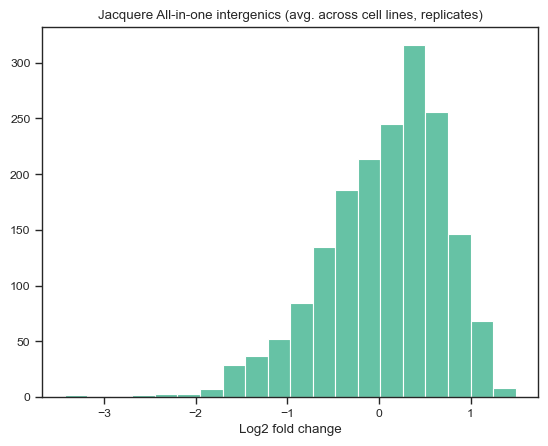

In [11]:
control_sgrna_lfcs = annotated_sgrna_lfcs[(annotated_sgrna_lfcs['Target Gene Symbol'].str.count("INTERGENIC")>0)].reset_index(drop=True)

#testing if controls are normally distributed with D'Agostino-Pearson K2 test
stat, p = normaltest(control_sgrna_lfcs["sgRNA_lfc"])
print('Statistics=%.3f, p=%.3f' % (stat, p),"length=",len(control_sgrna_lfcs))

control_sgrna_lfcs["sgRNA_lfc"].hist(grid=False,bins=20)
plt.title("Jacquere All-in-one intergenics (avg. across cell lines, replicates)")
plt.xlabel("Log2 fold change")

The result of the D'Agostino-Pearson K2 demonstrates that the controls are not normally distributed; z-scores should not be interpreted directly for statistical significance

In [12]:
control_sgrna_stats = (control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('sgRNA_lfc', 'mean'),
                            neg_ctl_sd = ('sgRNA_lfc', 'std'))
                       .reset_index())

zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='condition'))
zscored_sgrna_lfcs['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs['sgRNA_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean','sgRNA_lfc'], axis=1)
zscored_sgrna_lfcs

,Construct Barcode,condition,Target Gene ID,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score,z_scored_sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,Jacquere A375,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139,-1.226337
1,AAAAAAGAAAGGATACGTCC,Jacquere A549,ENSG00000189283,GENCODE,FHIT,ENST00000492590.6,NC_000003.12,+,60536861,5,0.5714,0,0,1.139,-1.012389
2,AAAAACAGCTGATGAAACCT,Jacquere A375,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047,-0.564372
3,AAAAACAGCTGATGAAACCT,Jacquere A549,ENSG00000116815,GENCODE,CD58,ENST00000369489.10,NC_000001.11,+,116544604,2,0.8133,0,0,0.5047,0.432301
4,AAAAACCTGGGAAAGATATA,Jacquere A375,ENSG00000188295,GENCODE,ZNF669,ENST00000448299.7,NC_000001.11,-,247101736,3,1.5184,0,0,0.958,0.312770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131587,TTTGTGGTAGGAGTAGGTGT,Jacquere A549,ENSG00000161999,GENCODE,JMJD8,ENST00000609261.6,NC_000016.10,+,683703,4,1.6667,0,0,0.9859,-1.437831
131588,TTTGTGTATTACCTCAGGAA,Jacquere A375,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334,-1.333360
131589,TTTGTGTATTACCTCAGGAA,Jacquere A549,ENSG00000189252,GENCODE,SPANXN3,ENST00000370503.2,NC_000023.11,-,143509068,2,0.7143,0,0,0.4334,-1.209296
131590,TTTGTTGGATACGAAGTGAA,Jacquere A375,ENSG00000120860,GENCODE,WASHC3,ENST00000240079.11,NC_000012.12,+,102046103,3,0.8667,0,0,0.3445,0.739569


In [19]:
essential_genes = pd.read_csv("../Data/AchillesCommonEssentialControls.csv")
essential_genes["Gene"]=essential_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
essential_genes["Gene"]=essential_genes["Gene"].str.replace(" ","")

noness_genes = pd.read_csv("../../2. Developing promiscuous classifier/Data/AchillesNonessentialControls.csv")
noness_genes["Gene"]=noness_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
noness_genes["Gene"]=noness_genes["Gene"].str.replace(" ","")
noness_gene_list=noness_genes["Gene"].tolist()

In [14]:
#subset to A375
essential_zscore_df=zscored_sgrna_lfcs[zscored_sgrna_lfcs["Target Gene Symbol"].isin(essential_genes["Gene"].tolist())]
essential_zscore_df=essential_zscore_df[essential_zscore_df["condition"]=="Jacquere A375"]
n_guides_per_gene=essential_zscore_df.groupby("Target Gene ID").agg(n_guides=("Construct Barcode","count")).reset_index()
genes_with_3_guides=n_guides_per_gene[n_guides_per_gene["n_guides"]==3]
essential_zscores_3guides_df= genes_with_3_guides.merge(essential_zscore_df,on="Target Gene ID",how="inner")
essential_zscores_3guides_df

,Target Gene ID,n_guides,Construct Barcode,condition,Source,Target Gene Symbol,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score,z_scored_sgRNA_lfc
0,ENSG00000001497,3,AAGCTCTTGGATGTAACTGG,Jacquere A375,GENCODE,LAS1L,ENST00000374811.8,NC_000023.11,-,65533664,2,0.0,0,0,1.494,-4.314054
1,ENSG00000001497,3,AGAACAGATAAACCGTCACC,Jacquere A375,GENCODE,LAS1L,ENST00000374811.8,NC_000023.11,+,65534555,1,0.0,0,0,1.512,-5.065194
2,ENSG00000001497,3,GAGTGCAGGCCCCTGAGCAG,Jacquere A375,GENCODE,LAS1L,ENST00000374811.8,NC_000023.11,+,65524201,10,2.5602,0,0,1.302,-6.061310
3,ENSG00000004779,3,AAGGAGGCATGTCGCTATAC,Jacquere A375,GENCODE,NDUFAB1,ENST00000007516.8,NC_000016.10,+,23587285,2,0.0,0,0,1.02,-4.358275
4,ENSG00000004779,3,AGTCACCTGCGCGAGCACTA,Jacquere A375,GENCODE,NDUFAB1,ENST00000007516.8,NC_000016.10,+,23596134,1,0.0,0,0,0.8418,-2.147454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3622,ENSG00000262814,3,AGACCTCAACGAGCTCCTGA,Jacquere A375,GENCODE,MRPL12,ENST00000333676.8,NC_000017.11,+,81704426,2,4.3333,0,0,0.9017,-5.838076
3623,ENSG00000262814,3,GAGTGAGGCTGGCGATGTCC,Jacquere A375,GENCODE,MRPL12,ENST00000333676.8,NC_000017.11,-,81704379,2,0.7,0,0,0.824,-4.517080
3624,ENSG00000291237,3,AGGAGGCGTTGGCCAAGGGT,Jacquere A375,GENCODE,SOD2,ENST00000538183.7,NC_000006.12,-,159692662,2,0.0,0,0,1.174,-2.453817
3625,ENSG00000291237,3,CCTGCACTGAAGTTCAATGG,Jacquere A375,GENCODE,SOD2,ENST00000538183.7,NC_000006.12,-,159688197,3,0.0,0,0,0.9609,-2.790645


In [25]:
bottom_5percent_intergenics=zscored_sgrna_lfcs[zscored_sgrna_lfcs['Target Gene Symbol'].str.count("INTERGENIC")>0]["z_scored_sgRNA_lfc"].quantile(0.05)
print(bottom_5percent_intergenics)

#identify the number of guides per essential gene that are more depleted than 95% of negative control guides
essential_zscores_depletedguides=essential_zscores_3guides_df[essential_zscores_3guides_df["z_scored_sgRNA_lfc"]<bottom_5percent_intergenics]
depletedguidecounts_essentials=essential_zscores_depletedguides.groupby("Target Gene ID").agg(n_guides=("Construct Barcode","count")).reset_index()
counts_of_counts=pd.DataFrame(depletedguidecounts_essentials["n_guides"].value_counts()).reset_index()
counts_of_counts=counts_of_counts.sort_values(by="n_guides",ascending=False)
counts_of_counts["n_guides"]=counts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides_brunello=len(essential_zscores_3guides_df[essential_zscores_3guides_df["Target Gene Symbol"].isin(essential_zscores_depletedguides["Target Gene Symbol"].tolist())==False]["Target Gene Symbol"].unique())
counts_of_counts = pd.concat([counts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides_brunello]})], ignore_index=True)
counts_of_counts

-1.8679726071482174


,n_guides,count
0,3,911
1,2,216
2,1,66
3,0,16


In [30]:
#repeat for brunello
brunello_zscores=pd.read_csv("../Data/brunello_zscores.csv")

#subset to top 3 guides by RS3 per gene
brunello_zscores['gene_RS3_rank'] = brunello_zscores.groupby('Target Gene ID')['On-Target Efficacy Score'].rank(method='min', ascending=False)
brunello_zscores=brunello_zscores[brunello_zscores["gene_RS3_rank"].isin([1,2,3])]

brunello_zscores = brunello_zscores.rename(columns={'sgRNA Sequence': 'Construct Barcode'})
brunello_essential_zscore_df=brunello_zscores[brunello_zscores["Target Gene Symbol"].isin(essential_genes["Gene"].tolist())]
n_guides_per_gene=brunello_essential_zscore_df.groupby("Target Gene ID").agg(n_guides=("Construct Barcode","count")).reset_index()
genes_with_3_guides=n_guides_per_gene[n_guides_per_gene["n_guides"]==3]
brunello_essential_zscores_3guides_df= genes_with_3_guides.merge(brunello_essential_zscore_df,on="Target Gene ID",how="inner")
bottom_5percent_brunello_intergenics=-1.56 # from Brunello_tracrv2_analysis.ipynb
brunello_essential_zscores_depletedguides=brunello_essential_zscores_3guides_df[brunello_essential_zscores_3guides_df["z_scored_sgRNA_lfc"]<bottom_5percent_brunello_intergenics]
brunellodepletedguidecounts_essentials=brunello_essential_zscores_depletedguides.groupby("Target Gene ID").agg(n_guides=("Construct Barcode","count")).reset_index()
brunellocounts_of_counts=pd.DataFrame(brunellodepletedguidecounts_essentials["n_guides"].value_counts()).reset_index()
brunellocounts_of_counts=brunellocounts_of_counts.sort_values(by="n_guides",ascending=False)
brunellocounts_of_counts["n_guides"]=brunellocounts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides_brunello=len(brunello_essential_zscore_df[brunello_essential_zscore_df["Target Gene Symbol"].isin(brunello_essential_zscores_depletedguides["Target Gene Symbol"].tolist())==False]["Target Gene Symbol"].unique())
brunellocounts_of_counts = pd.concat([brunellocounts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides_brunello]})], ignore_index=True)
brunellocounts_of_counts

,n_guides,count
0,3,699
1,2,328
2,1,152
3,0,59


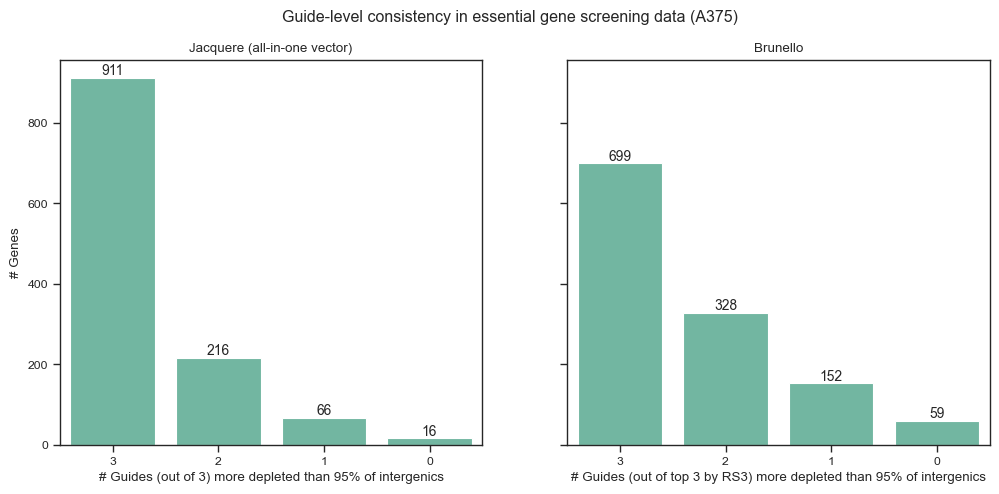

In [31]:


(fig,ax)=plt.subplots(1,2,figsize=(12,5),sharey=True)

fig.suptitle("Guide-level consistency in essential gene screening data (A375)")

sns.barplot(counts_of_counts,x="n_guides",y="count",ax=ax[0])
ax[0].set_xlabel("# Guides (out of 3) more depleted than 95% of intergenics")
ax[0].set_ylabel("# Genes")
ax[0].set_title("Jacquere (all-in-one vector)")
ax[0].bar_label(ax[0].containers[0], fontsize=10);


sns.barplot(brunellocounts_of_counts,x="n_guides",y="count",ax=ax[1])
ax[1].set_xlabel("# Guides (out of top 3 by RS3) more depleted than 95% of intergenics")
ax[1].set_ylabel("# Genes")
ax[1].set_title("Brunello")
ax[1].bar_label(ax[1].containers[0], fontsize=10);

gpp.savefig("../Figures/jacquere_allinone_guidelevelconsistency_vsbrunello.pdf")

In [26]:
nonessential_zscore_df=zscored_sgrna_lfcs[zscored_sgrna_lfcs["Target Gene Symbol"].isin(noness_genes["Gene"].tolist())]
nonessential_zscore_df=nonessential_zscore_df[nonessential_zscore_df["condition"]=="Jacquere A375"]
n_guides_per_gene=nonessential_zscore_df.groupby("Target Gene ID").agg(n_guides=("Construct Barcode","count")).reset_index()
genes_with_3_guides=n_guides_per_gene[n_guides_per_gene["n_guides"]==3]
nonessential_zscores_3guides_df= genes_with_3_guides.merge(nonessential_zscore_df,on="Target Gene ID",how="inner")

#identify the number of guides per essential gene that are more depleted than 95% of negative control guides
nonessential_zscores_depletedguides=nonessential_zscores_3guides_df[nonessential_zscores_3guides_df["z_scored_sgRNA_lfc"]<bottom_5percent_intergenics]
depletedguidecounts_nonessentials=nonessential_zscores_depletedguides.groupby("Target Gene ID").agg(n_guides=("Construct Barcode","count")).reset_index()
nonesscounts_of_counts=pd.DataFrame(depletedguidecounts_nonessentials["n_guides"].value_counts()).reset_index()
nonesscounts_of_counts=nonesscounts_of_counts.sort_values(by="n_guides",ascending=False)
nonesscounts_of_counts["n_guides"]=nonesscounts_of_counts["n_guides"].astype(str)
# number of genes with 0 depleted guides
num_genes_no_depleted_guides=len(nonessential_zscores_3guides_df[nonessential_zscores_3guides_df["Target Gene Symbol"].isin(nonessential_zscores_depletedguides["Target Gene Symbol"].tolist())==False]["Target Gene Symbol"].unique())
nonesscounts_of_counts = pd.concat([nonesscounts_of_counts, pd.DataFrame({'n_guides': ["0"], 'count': [num_genes_no_depleted_guides]})], ignore_index=True)
nonesscounts_of_counts

,n_guides,count
0,3,1
1,2,19
2,1,139
3,0,587


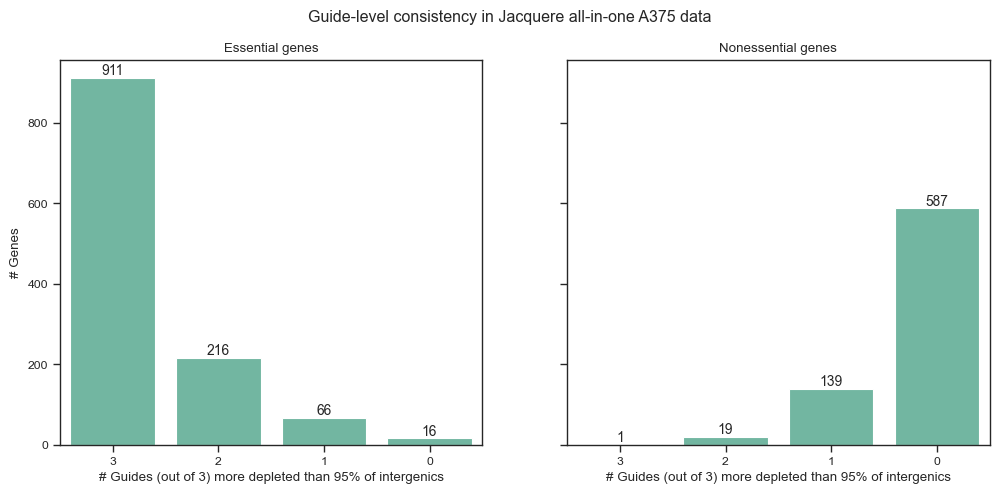

In [28]:


(fig,ax)=plt.subplots(1,2,figsize=(12,5),sharey=True)

fig.suptitle("Guide-level consistency in Jacquere all-in-one A375 data")

sns.barplot(counts_of_counts,x="n_guides",y="count",ax=ax[0])
ax[0].set_xlabel("# Guides (out of 3) more depleted than 95% of intergenics")
ax[0].set_ylabel("# Genes")
ax[0].set_title("Essential genes")
ax[0].bar_label(ax[0].containers[0], fontsize=10);


sns.barplot(nonesscounts_of_counts,x="n_guides",y="count",ax=ax[1])
ax[1].set_xlabel("# Guides (out of 3) more depleted than 95% of intergenics")
ax[1].set_ylabel("# Genes")
ax[1].set_title("Nonessential genes")
ax[1].bar_label(ax[1].containers[0], fontsize=10);

gpp.savefig("../Figures/jacquere_allinone_guidelevelconsistency_noness_vs_essential.pdf")